Visualize how SVM works. Demonstration of classical part.

In [6]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np

In [7]:
X, y = make_blobs(n_samples=40, centers=2, cluster_std=1.2, random_state=6)

In [8]:
from sklearn import svm


Fit the svm model using linear kernel


In [9]:
clf=svm.SVC(kernel='linear',C=1000) #C- forcing the model t find hard margin
clf.fit(X,y)

SVC(C=1000, kernel='linear')

Plot

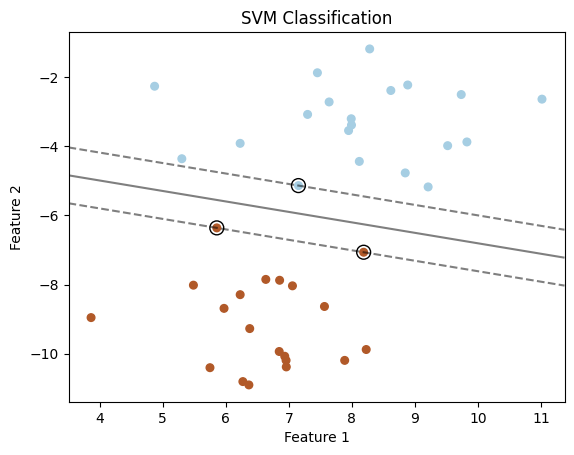

In [10]:
#Set up the plot
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired) # c for colouring s-size of dot cmap for colour palatte
#Plot the decision boundary (hyperplane)
ax = plt.gca() #gca- get current axes
xlim = ax.get_xlim() #get x and y limits
ylim = ax.get_ylim()
#Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 30) # to get evenly spaced numbers
yy = np.linspace(ylim[0], ylim[1], 30)# 30 for no of strips. sweet spot
YY, XX = np.meshgrid(yy, xx)#takes 30 horizontal and vertical points each and creates a grid
xy = np.vstack([XX.ravel(), YY.ravel()]).T #The .ravel() function is critical for translating the 2D visual grid into a format the machine learning model can understand.
Z = clf.decision_function(xy).reshape(XX.shape) #For every one of those 900 points, the SVM calculates its distance from the hyperplane.
#Plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--']) #alpha makes line slightly transparent
#Circle the support vectors
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k', label='Support Vectors')#support vectors hold the cooridnates of critical data points
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Classification')
plt.show()